# Notebook for analysing HCP Young Adults predictions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error

In [11]:
brainager = pd.read_csv("brainageR_imputed.csv")
pyment = pd.read_csv("pyment_imputed.csv")
hba = pd.read_csv("hba_hcp.csv")
metadata = pd.read_csv("HCP_metadata.csv")
hba


,eid,brainage,age
0,100307,19.446424,27
1,100408,28.789239,33
2,101107,21.921049,22
3,101309,21.154449,29
4,101915,23.139218,35
...,...,...,...
95,756055,14.268648,25
96,792564,22.492016,31
97,856766,13.358926,33
98,857263,13.506482,22


In [12]:
hba = hba.rename(columns={"eid": "Subject", "brainage":"predicted_age", "age":"Age_in_Yrs"})
hba = hba[["Subject","predicted_age","Age_in_Yrs"]]
hba = metadata[["Subject", "Age_in_Yrs","Gender"]].merge(hba[["Subject", "predicted_age", "Age_in_Yrs"]], 
                                                         on=["Subject", "Age_in_Yrs"], how="left")
hba


,Subject,Age_in_Yrs,Gender,predicted_age
0,100307,27,F,19.446424
1,100408,33,M,28.789239
2,101107,22,M,21.921049
3,101309,29,M,21.154449
4,101915,35,F,23.139218
...,...,...,...,...
95,756055,25,M,14.268648
96,792564,31,F,22.492016
97,856766,33,F,13.358926
98,857263,22,M,13.506482


In [14]:
pyment = pyment.rename(columns={"subject_id": "Subject"})
pyment = metadata[["Subject", "Age_in_Yrs","Gender"]].merge(pyment[["Subject", "predicted_age"]],
    on="Subject",
    how="left"
)
pyment

,Subject,Age_in_Yrs,Gender,predicted_age
0,100307,27,F,27.330000
1,100408,33,M,35.500000
2,101107,22,M,23.340000
3,101309,29,M,22.250000
4,101915,35,F,31.020000
...,...,...,...,...
95,756055,25,M,28.311753
96,792564,31,F,30.860000
97,856766,33,F,30.100000
98,857263,22,M,25.280000


In [15]:
brainager = brainager.rename(columns={
    "subject_id": "Subject",
    "brain.predicted_age": "predicted_age"
})


In [16]:
brainager = metadata[["Subject", "Age_in_Yrs", "Gender"]].merge(
    brainager[["Subject", "predicted_age"]],
    on="Subject",
    how="left"
)

In [17]:
brainager

,Subject,Age_in_Yrs,Gender,predicted_age
0,100307,27,F,41.0982
1,100408,33,M,29.5412
2,101107,22,M,29.5412
3,101309,29,M,29.5412
4,101915,35,F,37.5130
...,...,...,...,...
95,756055,25,M,36.7616
96,792564,31,F,28.0950
97,856766,33,F,35.5619
98,857263,22,M,18.5374


In [18]:
brainager["BAG"] = brainager["predicted_age"] - brainager["Age_in_Yrs"]
pyment["BAG"] = pyment["predicted_age"] - pyment["Age_in_Yrs"]
hba["BAG"] = hba["predicted_age"] - hba["Age_in_Yrs"]

In [19]:
models = {
    "brainageR": brainager,
    "pyment": pyment,
    "HBA": hba
}

for name, df in models.items():
    y_true = df["Age_in_Yrs"]
    y_pred = df["predicted_age"]
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
    r, p_r   = stats.pearsonr(y_true, y_pred)
    rho, p_s = stats.spearmanr(y_true, y_pred)

    print(f"\n── {name} validation (N={len(df)} HCP YA) ──")
    print(f"MAE:        {mae:.2f} years")
    print(f"RMSE:       {rmse:.2f} years")
    print(f"Pearson r:  {r:.3f}  (p={p_r:.4f})")
    print(f"Spearman ρ: {rho:.3f}  (p={p_s:.4f})")
    print(f"BAG:        mean={df['BAG'].mean():.2f}, SD={df['BAG'].std():.2f}")


── brainageR validation (N=100 HCP YA) ──
MAE:        5.93 years
RMSE:       7.75 years
Pearson r:  0.305  (p=0.0020)
Spearman ρ: 0.276  (p=0.0055)
BAG:        mean=4.11, SD=6.60

── pyment validation (N=100 HCP YA) ──
MAE:        2.97 years
RMSE:       3.76 years
Pearson r:  0.517  (p=0.0000)
Spearman ρ: 0.596  (p=0.0000)
BAG:        mean=-0.75, SD=3.71

── HBA validation (N=100 HCP YA) ──
MAE:        7.07 years
RMSE:       8.55 years
Pearson r:  0.351  (p=0.0003)
Spearman ρ: 0.363  (p=0.0002)
BAG:        mean=-6.01, SD=6.11


## Visualizations

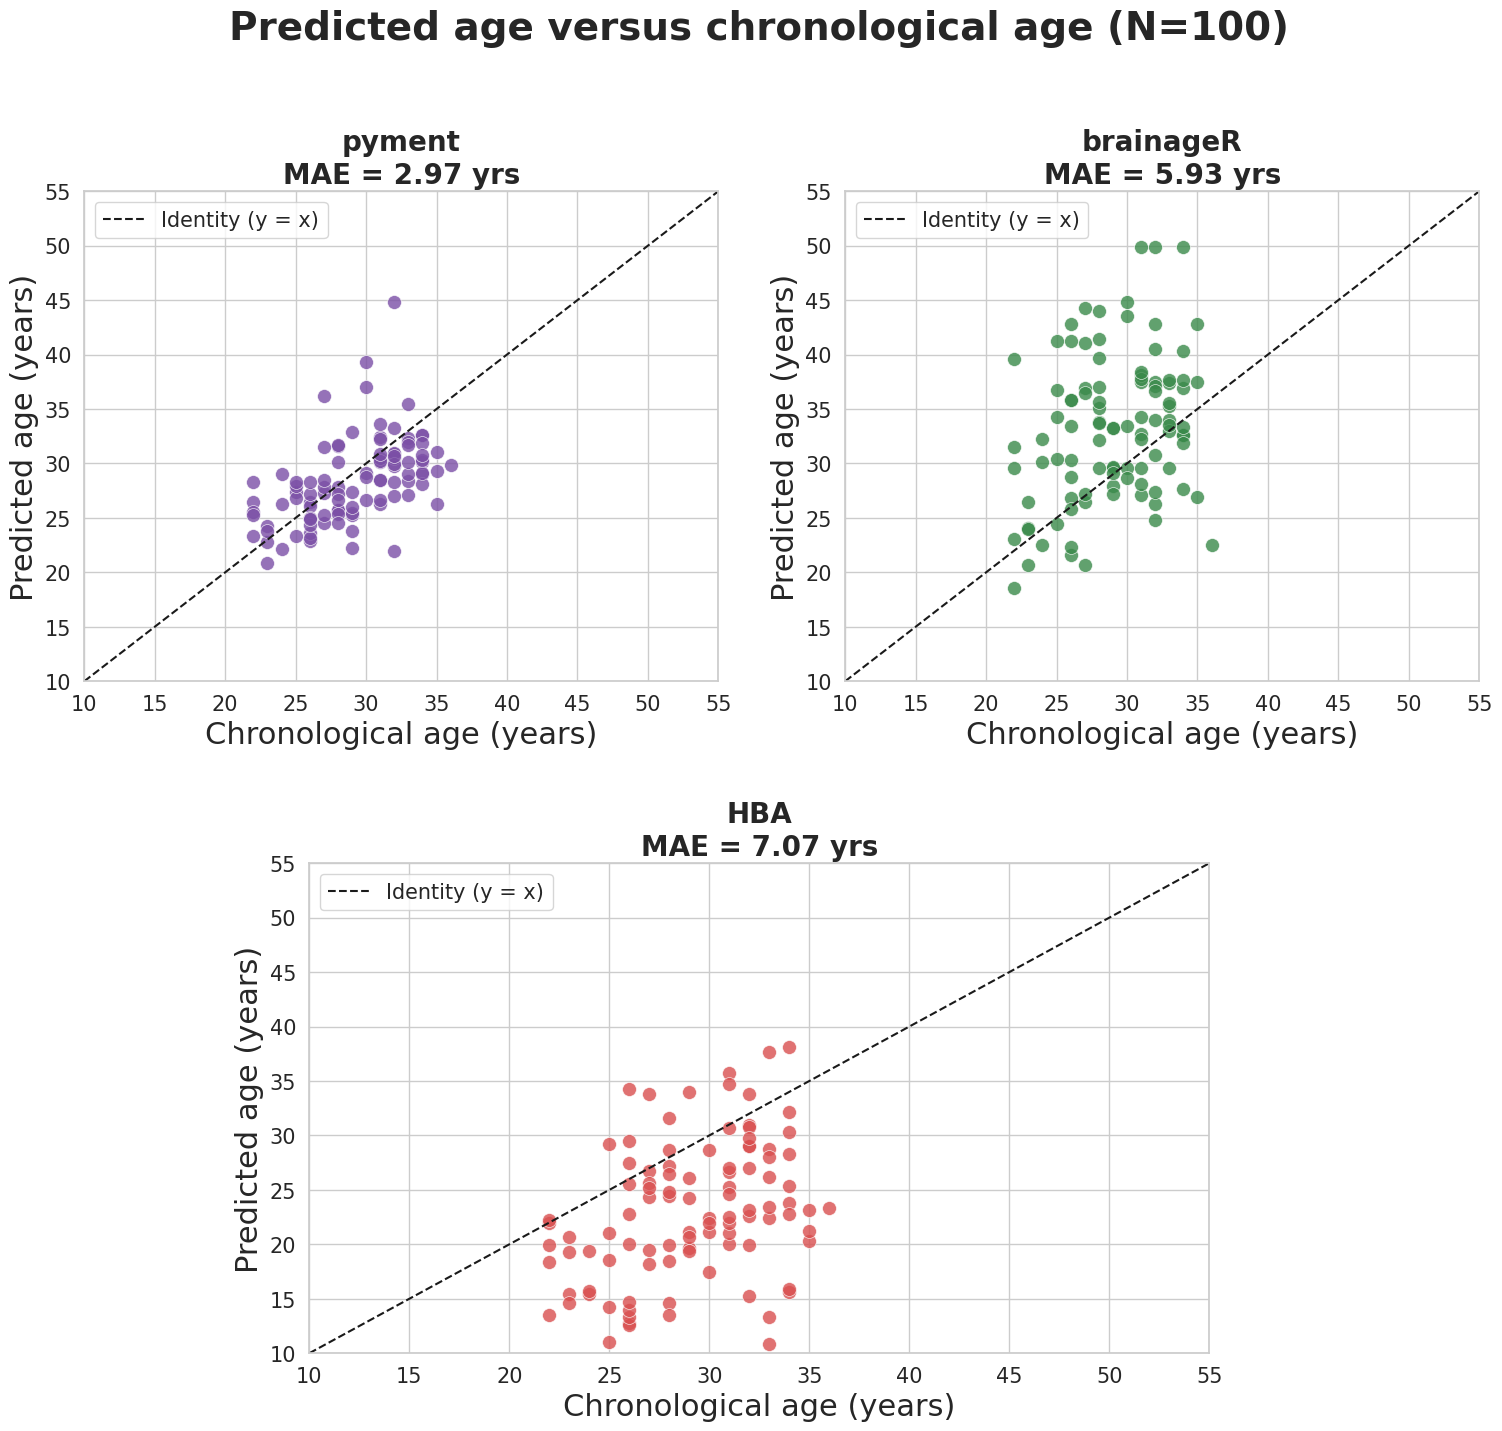

In [31]:
import seaborn as sns
sns.set_theme(style="whitegrid")

models = {
    "pyment": pyment,
    "brainageR": brainager,
    "HBA": hba
}
palette_models = {
    "pyment":    "#7B4FA6",
    "brainageR": "#3A8A4A",
    "HBA":       "#D94F4F",
}

age_min, age_max = 10, 55
x_line = np.array([age_min, age_max])
#palette = {"M": "#4CAF82", "F": "#9B6BB5"}

fig = plt.figure(figsize=(18, 14))

axes = [
    fig.add_subplot(2, 2, 1),
    fig.add_subplot(2, 2, 2),
    fig.add_subplot(2, 2, (3, 4))
]

# ── sentrerer tredje subplot ───────────────────────────────────────────────────
axes[2].set_position([0.25, 0.05, 0.5, 0.35])

fig.suptitle("Predicted age versus chronological age (N=100)",
             fontsize=28, fontweight="bold", y=1.01)

for ax, (name, df) in zip(axes, models.items()):
    mae  = mean_absolute_error(df["Age_in_Yrs"], df["predicted_age"])
    rmse = np.sqrt(np.mean((df["predicted_age"] - df["Age_in_Yrs"]) ** 2))

    sns.scatterplot(data=df, x="Age_in_Yrs", y="predicted_age",
                    color=palette_models[name], alpha=0.8,
                    edgecolor="white", linewidth=0.5, s=100, ax=ax)

    ax.plot([age_min, age_max], [age_min, age_max], "k--", lw=1.5,
            label="Identity (y = x)")

    ax.set_xlim(age_min, age_max)
    ax.set_ylim(age_min, age_max)
    ax.set_xlabel("Chronological age (years)", fontsize=22)
    ax.set_ylabel("Predicted age (years)", fontsize=22)
    ax.set_title(f"{name}\nMAE = {mae:.2f} yrs",
                 fontsize=20, fontweight="bold")
    ax.tick_params(axis="both", labelsize=15)
    ax.legend(fontsize=15)

plt.savefig("pred_vs_ca.png", dpi=150, bbox_inches="tight")
plt.show()

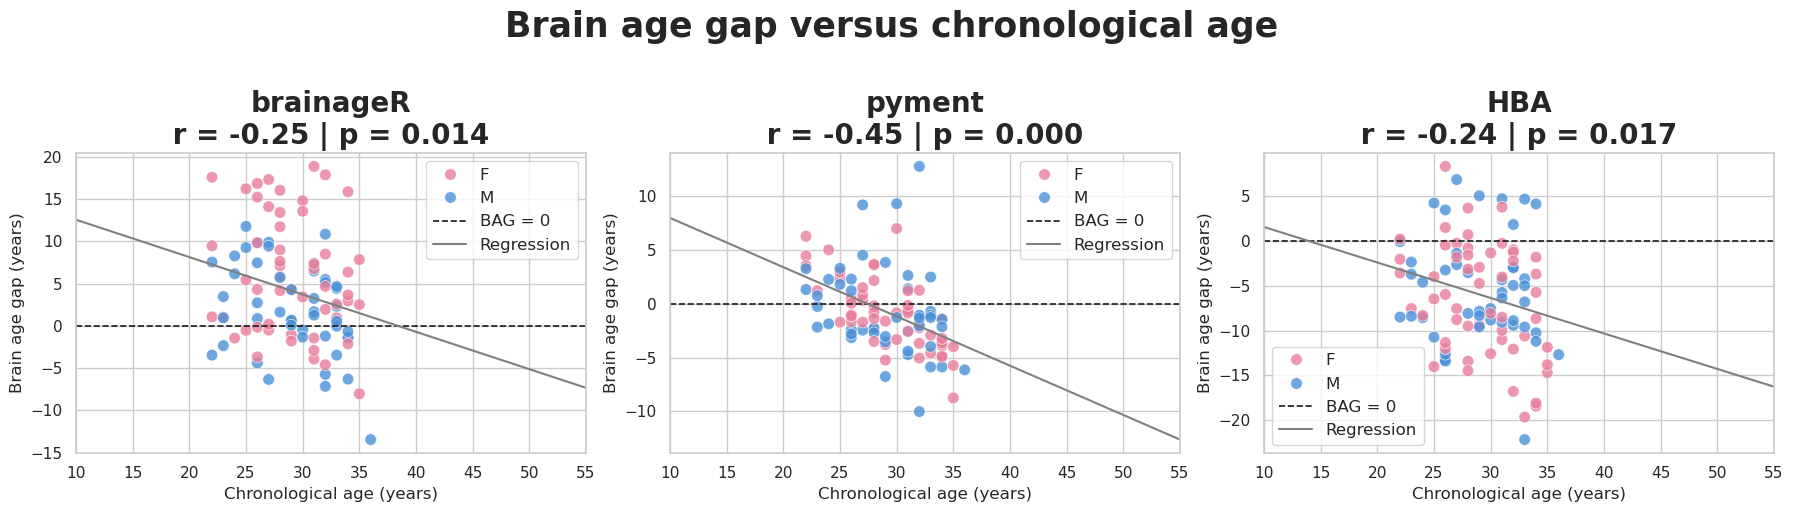

In [25]:
# ── BAG vs chronological age ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))
fig.suptitle("Brain age gap versus chronological age", fontsize=25, fontweight="bold", y=1.02)

for ax, (name, df) in zip(axes, models.items()):
    slope_b, intercept_b, r_b, p_b, *_ = stats.linregress(df["Age_in_Yrs"], df["BAG"])

    sns.scatterplot(data=df, x="Age_in_Yrs", y="BAG",
                    hue="Gender", palette=palette, alpha=0.8,
                    edgecolor="white", linewidth=0.5, s=70, ax=ax)
    ax.axhline(0, color="k", lw=1.2, linestyle="--", label="BAG = 0")
    ax.plot(x_line, intercept_b + slope_b * x_line, color="gray", lw=1.5,
            label=f"Regression")
    ax.set_xlim(age_min, age_max)
    ax.set_xlabel("Chronological age (years)")
    ax.set_ylabel("Brain age gap (years)")
    ax.set_title(f"{name}\n r = {r_b:.2f} | p = {p_b:.3f} ", fontsize=20, fontweight = "bold")
    ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig("bag_vs_ca.png", dpi=150, bbox_inches="tight")
plt.show()